# Comparing Data Sets.
____

In [138]:
from pathlib import Path
from microlive.imports import *
from microlive import microscopy as mi
current_dir = Path().resolve()
parent_dir = current_dir.parents[1]
main_dir = Path().resolve().parent
one_drive_dir = mi.Utilities.get_one_drive_dir()
import sys
repo_root = Path().resolve().parents[1]  # Go up to cof_paper/
sys.path.insert(0, str(repo_root))

import utilities as ld
importlib.reload(ld)


<module 'utilities' from 'C:\\Users\\searsrh\\OneDrive - The University of Colorado Denver\\Desktop\\cof_paper\\utilities\\__init__.py'>

## Loading data and strings for subclassification
___

In [139]:
# Loading data
        #RMS External Drive Location:    'E:/Co-translational folding (CoF) paper/Fig 5_Fast coTFT minitrack analysis'
        #Ning Zhao OneDrive Location:    '...General - Zhao (NZ) Lab\Zhao lab shared folder\Our papers\co-translational folding paper\Fig 5\Fig 5_Fast coTFT minitrack analysis'
dataframes_dir = Path('E:/Co-translational folding (CoF) paper/Fig 5_Fast coTFT minitrack analysis')

# Average Folder Substrings

list_folder_substring_to_avoid = None


save_dir = current_dir.joinpath('results_Fig5_fast')
save_dir.mkdir(parents=True, exist_ok=True)

# Individual day Folder Substrings
plot_individual_days = False     # Set to False to skip plotting individual experiment days and plot the overall average.

list_folder_substrings, list_names = ld.get_folder_substrings_and_names(
    dataframes_dir, 
    process_individual_days=plot_individual_days,
)
print(list_folder_substrings)
print(list_names)


Found 2 plasmids in 28 folders
  pRS084: 2 experiment(s)
  pRS027: 1 experiment(s)
['pRS027', 'pRS084']
['4sfGFP-2mCh', '4sfGFP-deopt-2mCh']


In [140]:
#rearrange the data in the graphs

#list_folder_substrings = ['pRS027','pRS084']
#list_names = ['4xsfGFP', '4sfGFP deopt']

## Loading the data
____

In [141]:
data_dict = ld.aggregate_folder_data(dataframes_dir,list_folder_substrings,
            list_folder_substring_to_avoid,list_folder_substring_second_condition=None,
            show_file_names=True, verbose= False)

Loaded results_20260318 pRS027_012_JF646 6hr Tfx_Series001 (2 channels)
Loaded results_20260318 pRS027_012_JF646 6hr Tfx_Series002 (2 channels)
Loaded results_20260318 pRS027_012_JF646 6hr Tfx_Series005 (2 channels)
Loaded results_20260318 pRS027_012_JF646 6hr Tfx_Series005-1 (2 channels)
Loaded results_20260318 pRS027_012_JF646 6hr Tfx_Series006 (2 channels)
Loaded results_20260318 pRS027_012_JF646 6hr Tfx_Series007 (2 channels)
Loaded results_20260318 pRS027_012_JF646 6hr Tfx_Series009 (2 channels)
Loaded results_20260318 pRS027_012_JF646 6hr Tfx_Series010 (2 channels)
Loaded results_20260318 pRS027_012_JF646 6hr Tfx_Series011 (2 channels)
Loaded results_20260318 pRS027_012_JF646 6hr Tfx_Series012 (2 channels)
Loaded results_20260318 pRS027_012_JF646 6hr Tfx_Series013 (2 channels)
Loaded results_20260318 pRS027_012_JF646 6hr Tfx_Series014 (2 channels)
Loaded results_20260318 pRS027_012_JF646 6hr Tfx_Series015 (2 channels)
Loaded results_20260318 pRS027_012_JF646 6hr Tfx_Series016 (2 

## Plotting Configuration
___

In [155]:
# ── Plotting Configuration ─────────────────────────────────
PLOT_CONFIG = dict(
    figsize       = (3, 4),
    tick_size     = 10,
    swarm_color   = 'black',
    show_stats    = True,
    only_significant = True,
    max_percentile_significance = 99.5,
)

SAVE_DIR = save_dir  # Defined in data config above; set to None to skip saving


## Plotting data
___

In [156]:
for key in data_dict.keys():
    print(key)


directories
int_ch_0
int_ch_1
snr_ch_0
snr_ch_1
spot_size_ch_0
spot_size_ch_1
total_spot_int_ch_0
total_spot_int_ch_1
spot_amplitude_ch_0
spot_amplitude_ch_1
spot_sigma_ch_0
spot_sigma_ch_1
number_spots
frames
number_of_color_channels
average_number_spots
efficiency_ml
efficiency_manual


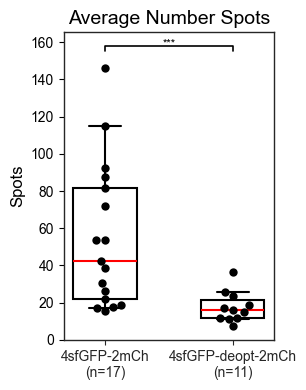

<Axes: title={'center': 'Average Number Spots'}, ylabel='Spots'>

In [157]:
ld.plot_swarm_plot(
    data_dict['average_number_spots'], list_names,
    y_label='Spots',
    title='Average Number Spots',
    y_lim=(0, 200),
    plot_name='avg_spots',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


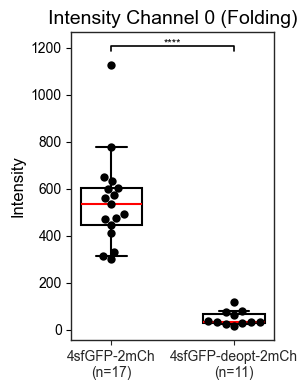

<Axes: title={'center': 'Intensity Channel 0 (Folding)'}, ylabel='Intensity'>

In [158]:
ld.plot_swarm_plot(
    data_dict['int_ch_0'], list_names,
    y_label='Intensity',
    title='Intensity Channel 0 (Folding)',
    y_lim=(-100, 2000),
    plot_name='int_ch0',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


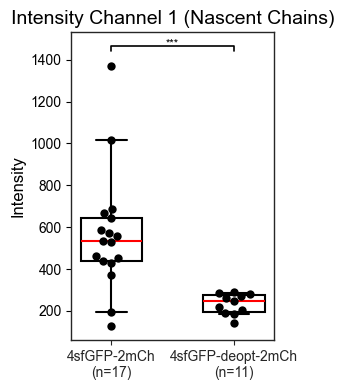

<Axes: title={'center': 'Intensity Channel 1 (Nascent Chains)'}, ylabel='Intensity'>

In [159]:
ld.plot_swarm_plot(
    data_dict['int_ch_1'], list_names,
    y_label='Intensity',
    title='Intensity Channel 1 (Nascent Chains)',
    y_lim=(0, 2000),
    plot_name='int_ch1',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


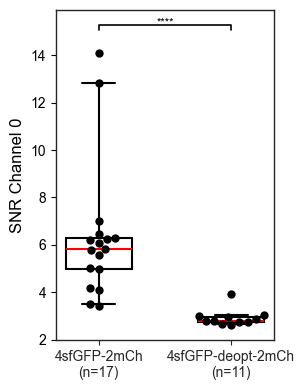

<Axes: ylabel='SNR Channel 0'>

In [160]:
ld.plot_swarm_plot(
    data_dict['snr_ch_0'], list_names,
    y_label='SNR Channel 0',
    plot_name='snr_ch0',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


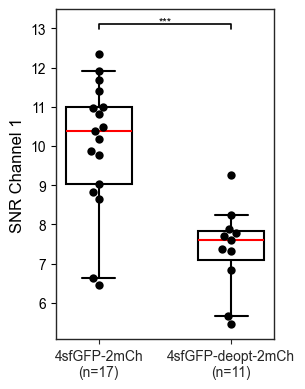

<Axes: ylabel='SNR Channel 1'>

In [161]:
ld.plot_swarm_plot(
    data_dict['snr_ch_1'], list_names,
    y_label='SNR Channel 1',
    plot_name='snr_ch1',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


## Calculating Folding Efficiency using ML method

___

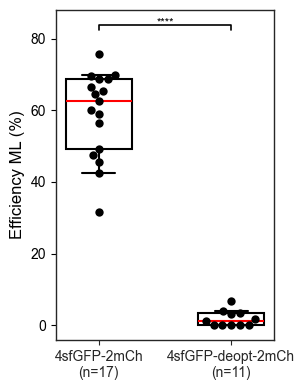

<Axes: ylabel='Efficiency ML (%)'>

In [169]:
ld.plot_swarm_plot(
    data_dict['efficiency_ml'], list_names,
    y_label='Efficiency ML (%)',
    y_lim=(-10, 100),
    plot_name='efficiency_ml',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


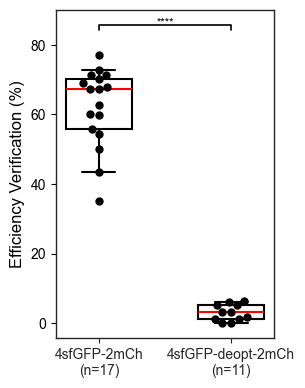

<Axes: ylabel='Efficiency Verification (%)'>

In [170]:
ld.plot_swarm_plot(
    data_dict['efficiency_manual'], list_names,
    y_label='Efficiency Verification (%)',
    y_lim=(-10, 100),
    plot_name='efficiency_verification',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


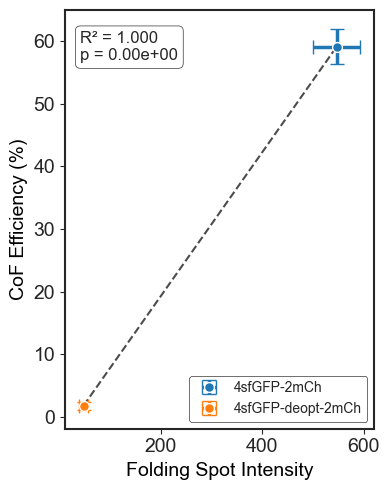

<Axes: xlabel='Folding Spot Intensity', ylabel='CoF Efficiency (%)'>

In [171]:
ld.plot_efficiency_vs_intensity_scatter_means(
    data_dict, list_names,
    x_label='Folding Spot Intensity',
    y_label='CoF Efficiency (%)',
    figsize= (4, 5), #PLOT_CONFIG['figsize']
    tick_size=PLOT_CONFIG['tick_size'],
    marker_size=50,
    save_dir=SAVE_DIR,
    plot_name='intensity_efficiency',
    show_legend=True,
    
)


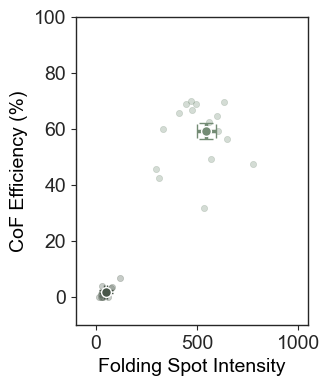

<Axes: xlabel='Folding Spot Intensity', ylabel='CoF Efficiency (%)'>

In [172]:
ld.plot_efficiency_vs_intensity_scatter_means(
    data_dict, list_names,
    intensity_key='int_ch_0',
    x_label='Folding Spot Intensity',
    y_label='CoF Efficiency (%)',
    figsize=PLOT_CONFIG['figsize'],
    tick_size=PLOT_CONFIG['tick_size'],
    marker_size=50,
    save_dir=SAVE_DIR,
    plot_name='intensity_efficiency_folded',
    colors=["#738B74", '#485649'], #deopt #485649
    show_individual_cells=True,
    show_regression_line=False, 
    x_lim=(-100, 1050),
    y_lim=(-10, 100),  

)


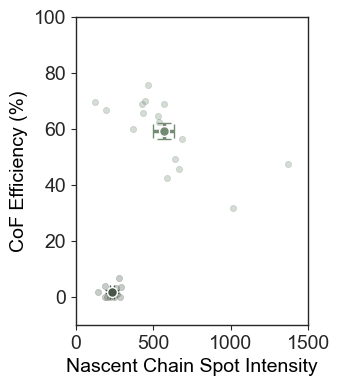

<Axes: xlabel='Nascent Chain Spot Intensity', ylabel='CoF Efficiency (%)'>

In [175]:
ld.plot_efficiency_vs_intensity_scatter_means(
    data_dict, list_names,
    intensity_key='int_ch_1',
    x_label='Nascent Chain Spot Intensity',
    y_label='CoF Efficiency (%)',
    figsize=PLOT_CONFIG['figsize'],
    tick_size=PLOT_CONFIG['tick_size'],
    marker_size=50,
    save_dir=SAVE_DIR,
    plot_name='intensity_efficiency_NC',
    colors=["#738B74", '#485649'],
    show_individual_cells=True,
    show_regression_line=False, 
    x_lim=(0, 1500),
    y_lim=(-10, 100),  

)


In [174]:
SAVE_DIR

WindowsPath('C:/Users/searsrh/OneDrive - The University of Colorado Denver/Desktop/cof_paper/notebooks/CoF_project/results_Fig5_fast')